## Fine Tuning a base language model to improve prediction of stock prices using a sythentic data set of 220 samples created using severalmarket indicators including market sentiments. THe model was fine tuned to learn  the relationship between this indicators and a target stock price.

In [35]:
## Install Dependancies and Packages
!pip install openai pandas numpy scikit-learn matplotlib python-dotenv tqdm

In [ ]:
## Imports

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from openai import OpenAI
import time
import itertools
import sys


In [37]:
## Load API Keys

load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("OPENAI_API_KEY not found")

In [38]:
PROJECT_DIR = "/home/steve/llm_engineering/community-contributions/steve"

DATA_FILE = f"{PROJECT_DIR}/stock_price_training_data_220.jsonl"
TRAIN_FILE = f"{PROJECT_DIR}/stock_train.jsonl"
VAL_FILE = f"{PROJECT_DIR}/stock_val.jsonl"

In [39]:
## Load Data Set
with open(DATA_FILE) as f:
    lines = f.readlines()

print("Total examples:", len(lines))

Total examples: 220


In [40]:
## Train/Validation Split

train_lines, val_lines = train_test_split(
    lines,
    test_size=0.1,
    random_state=42
)

print("Train samples:", len(train_lines))
print("Validation samples:", len(val_lines))

Train samples: 198
Validation samples: 22


In [41]:
## Save Train/Validation Files

with open(TRAIN_FILE, "w") as f:
    for line in train_lines:
        f.write(line)

with open(VAL_FILE, "w") as f:
    for line in val_lines:
        f.write(line)

print("Files saved successfully")

Files saved successfully


In [42]:
## Upload Files for Fine Tuning

train_file = client.files.create(
    file=open(TRAIN_FILE, "rb"),
    purpose="fine-tune"
)

val_file = client.files.create(
    file=open(VAL_FILE, "rb"),
    purpose="fine-tune"
)

print("Train File ID:", train_file.id)
print("Validation File ID:", val_file.id)

Train File ID: file-8ftqnnvX2iEgQBmRNsD2UW
Validation File ID: file-5MF4MmUhEc7Dwx543UYi9S


In [43]:
## Activate fine-tuning job

job = client.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=val_file.id,
    model="gpt-3.5-turbo",
    hyperparameters={
        "n_epochs":5,
        "batch_size":2,
        "learning_rate_multiplier":0.5
    }
)

job

FineTuningJob(id='ftjob-x3tcyDjW8ZHYaynzrSBgR1cL', created_at=1772786530, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size=2, learning_rate_multiplier=0.5, n_epochs=5), model='gpt-3.5-turbo-0125', object='fine_tuning.job', organization_id='org-LpwrCqadudUlTiynlwF0wefY', result_files=[], seed=232492666, status='validating_files', trained_tokens=None, training_file='file-8ftqnnvX2iEgQBmRNsD2UW', validation_file='file-5MF4MmUhEc7Dwx543UYi9S', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=2, learning_rate_multiplier=0.5, n_epochs=5))), user_provided_suffix=None, usage_metrics=None, shared_with_openai=False, eval_id=None, internal_worker_backend=None, internal_peashooter_execution=None, train_experiment_id=None, eval_experiment_id=None)

In [44]:
## Monitor Training
client.fine_tuning.jobs.retrieve(job.id)

FineTuningJob(id='ftjob-x3tcyDjW8ZHYaynzrSBgR1cL', created_at=1772786530, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size=2, learning_rate_multiplier=0.5, n_epochs=5), model='gpt-3.5-turbo-0125', object='fine_tuning.job', organization_id='org-LpwrCqadudUlTiynlwF0wefY', result_files=[], seed=232492666, status='validating_files', trained_tokens=None, training_file='file-8ftqnnvX2iEgQBmRNsD2UW', validation_file='file-5MF4MmUhEc7Dwx543UYi9S', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=2, learning_rate_multiplier=0.5, n_epochs=5))), user_provided_suffix=None, usage_metrics=None, shared_with_openai=False, eval_id=None, internal_worker_backend=None, internal_peashooter_execution=None, train_experiment_id=None, eval_experiment_id=None)

In [58]:
## When status changes to succeded , move to the next cell

import time
from IPython.display import clear_output

while True:
    
    status = client.fine_tuning.jobs.retrieve(job.id).status
    
    clear_output(wait=True)
    print("Fine-tuning job status:", status)
    
    if status in ["succeeded", "failed"]:
        break
        
    time.sleep(20)



Fine-tuning job status: succeeded


In [59]:
## Retrieve Fine Tuned Model
job_status = client.fine_tuning.jobs.retrieve(job.id)

model_name = job_status.fine_tuned_model

print("Fine Tuned Model:", model_name)

Fine Tuned Model: ft:gpt-3.5-turbo-0125:personal::DGLKv6DU


In [80]:
## Prediction Helper Function
import re

def predict_price(model, prompt):

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "You are a quantitative financial model. Respond with ONLY a number."
            },
            {
                "role": "user",
                "content": "This is a regression exercise. Estimate a numeric stock price from the indicators below.\n\n" + prompt
            }
        ]
    )

    text = response.choices[0].message.content

    match = re.search(r"\d+\.?\d*", text)

    if match:
        return float(match.group())

    print("Bad response:", text)
    return None

In [81]:
## Load Validation Dataset
records = []

with open(VAL_FILE) as f:
    for line in f:
        records.append(json.loads(line))

In [82]:
## Extract prompts and actual prices
prompts = []
true_prices = []

for r in records:

    user_prompt = r["messages"][1]["content"]
    price = float(r["messages"][2]["content"])

    prompts.append(user_prompt)
    true_prices.append(price)

In [83]:
## Evaluate Base Model

base_predictions = []

for prompt in prompts:

    pred = predict_price("gpt-3.5-turbo", prompt)
    base_predictions.append(pred)

In [84]:
## Fine Tuned Model Predictions

fine_predictions = []

for prompt in prompts:
    pred = predict_price(model_name, prompt)
    fine_predictions.append(pred)

In [85]:
## Calculate Margin of Error

clean_true = []
clean_base = []
clean_fine = []

for t, b, f in zip(true_prices, base_predictions, fine_predictions):

    if b is not None and f is not None:
        clean_true.append(t)
        clean_base.append(b)
        clean_fine.append(f)

clean_true = np.array(clean_true)
clean_base = np.array(clean_base)
clean_fine = np.array(clean_fine)

base_mae = np.mean(np.abs(clean_true - clean_base))
fine_mae = np.mean(np.abs(clean_true - clean_fine))

print("Base Model MAE:", base_mae)
print("Fine Tuned Model MAE:", fine_mae)

Base Model MAE: 584.9227272727273
Fine Tuned Model MAE: 180.32272727272726


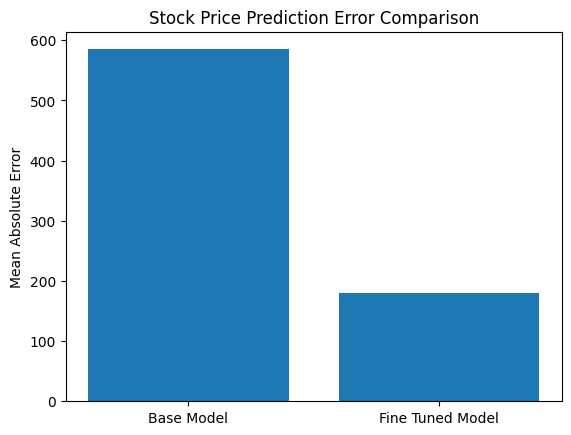

In [86]:
## Error Comparison Graph
models = ["Base Model", "Fine Tuned Model"]
errors = [base_mae, fine_mae]

plt.figure()

plt.bar(models, errors)

plt.title("Stock Price Prediction Error Comparison")
plt.ylabel("Mean Absolute Error")

plt.show()

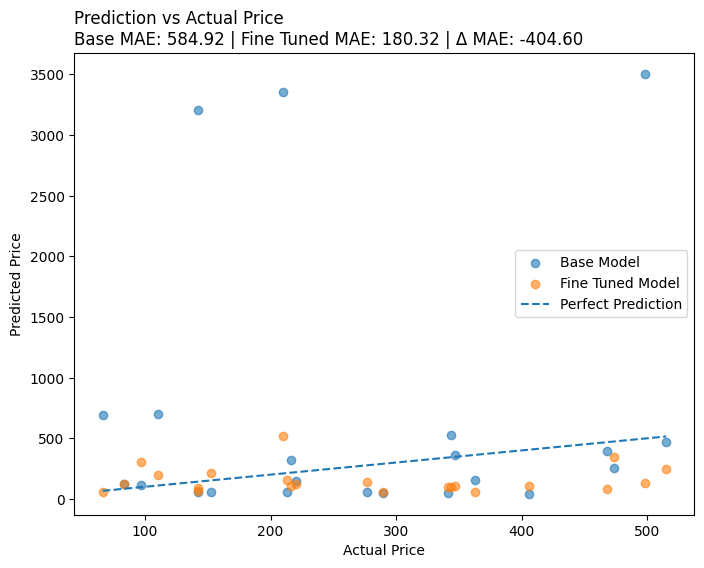

In [ ]:
## Prediction vs Actual Graph with Best Fit Lines
plt.figure(figsize=(8,6))

# Scatter points
plt.scatter(true_prices, base_predictions, alpha=0.6, label="Base Model")
plt.scatter(true_prices, fine_predictions, alpha=0.6, label="Fine Tuned Model")

# Perfect prediction line
min_price = min(true_prices)
max_price = max(true_prices)

plt.plot([min_price, max_price], [min_price, max_price], linestyle="--", label="Perfect Prediction")

# Calculate improvement
improvement = fine_mae - base_mae

# Title with MAE metrics
plt.title(
    f"Prediction vs Actual Stock Price\n"
    f"Base MAE: {base_mae:.2f} | Fine Tuned MAE: {fine_mae:.2f} | Δ MAE: {improvement:+.2f}",
    loc="left"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.legend()

plt.show()
